In [1]:
import torch
from torch.utils.data import Dataset

class TinyShakespeare(Dataset):
    def __init__(self, seq_len: int):
        with open("tiny_shakespeare.txt", "r") as f:
            text = f.read()
        unique_chars = set(text)
        self.vocab_size = len(unique_chars)

        self.ctoi = {c: i for (i, c) in enumerate(unique_chars)}
        self.itoc = {self.ctoi[c]: c for c in self.ctoi.keys()}

        self.tokens = self.chars_to_tokens(text)

        self.seq_len = seq_len
        self.len = len(self.tokens) - self.seq_len

    def __len__(self):
        return self.len
    
    def __getitem__(self, idx: int):
        return (self.tokens[idx : idx+self.seq_len], self.tokens[idx+1 : idx+1+self.seq_len])
    
    def tokens_to_chars(self, tokens: torch.Tensor):
        return [self.itoc[x.item()] for x in tokens]
    
    def chars_to_tokens(self, chars: str):
        return torch.tensor([self.ctoi[c] for c in chars], dtype=torch.int64)
    
dataset = TinyShakespeare(16)
print(len(dataset), dataset.vocab_size)
print(dataset[0])

1114943 62
(tensor([43, 36, 40, 61, 11,  5, 22, 36, 11, 36, 47, 26, 20, 13, 33, 56]), tensor([36, 40, 61, 11,  5, 22, 36, 11, 36, 47, 26, 20, 13, 33, 56, 26]))


In [2]:
from functools import partial
import torch.nn.functional as F
from torch import nn

class Gate(nn.Module):
    def __init__(self, in_dim: int, hidden_dim: int, act):
        super().__init__()
        self.Wxh = nn.Linear(in_dim, hidden_dim, bias=False)
        self.Whh = nn.Linear(hidden_dim, hidden_dim, bias=True)
        self.act = act

    def forward(self, x: torch.Tensor, h: torch.Tensor):
        return self.act(self.Wxh(x) + self.Whh(h))


class RNN(nn.Module):
    def __init__(self, in_dim: int, hidden_dim: int, out_dim: int):
        super().__init__()
        self.gate = Gate(in_dim, hidden_dim, act=F.tanh)
        self.Who = nn.Linear(hidden_dim, out_dim, bias=True)
        self.hidden_dim = hidden_dim

    def forward(self, x: torch.Tensor, state: torch.Tensor | None = None):
        B, T, _ = x.shape
        if state is None:
            state = torch.zeros((B, self.hidden_dim), dtype=x.dtype, device=x.device, requires_grad=False)

        outputs = []
        for t in range(T):
            state = self.gate(x[:, t], state)
            output = self.Who(state)
            outputs.append(output)
        return torch.stack(outputs, dim=1), state
    

class LSTM(nn.Module):
    def __init__(self, in_dim: int, hidden_dim: int, out_dim: int):
        super().__init__()
        self.forget_gate = Gate(in_dim, hidden_dim, act=F.sigmoid)
        self.input_gate = Gate(in_dim, hidden_dim, act=F.sigmoid)
        self.input_node = Gate(in_dim, hidden_dim, act=F.tanh)
        self.output_gate = Gate(in_dim, hidden_dim, act=F.sigmoid)
        self.Who = nn.Linear(hidden_dim, out_dim, bias=True)
        self.hidden_dim = hidden_dim

    def forward(self, x: torch.Tensor, state: tuple[torch.Tensor, torch.Tensor] | None = None):
        B, T, _ = x.shape
        if state is None:
            int_state = torch.zeros((B, self.hidden_dim), dtype=x.dtype, device=x.device, requires_grad=False)
            hidden_state = torch.zeros((B, self.hidden_dim), dtype=x.dtype, device=x.device, requires_grad=False)
        else:
            int_state, hidden_state = state

        outputs = []
        for t in range(T):
            int_state = (self.forget_gate(x[:, t], hidden_state) * int_state) + (self.input_gate(x[:, t], hidden_state) * self.input_node(x[:, t], hidden_state))
            hidden_state = F.tanh(int_state) * self.output_gate(x[:, t], hidden_state)
            output = self.Who(hidden_state)
            outputs.append(output)
        return torch.stack(outputs, dim=1), (int_state, hidden_state)


rnn = RNN(in_dim=32, hidden_dim=64, out_dim=16)
outputs, state = rnn(torch.empty((8, 100, 32)))
print(outputs.shape, state.shape)

lstm = LSTM(in_dim=32, hidden_dim=64, out_dim=16)
outputs, (int_state, hidden_state) = lstm(torch.empty((8, 100, 32)))
print(outputs.shape, int_state.shape, hidden_state.shape)

torch.Size([8, 100, 16]) torch.Size([8, 64])
torch.Size([8, 100, 16]) torch.Size([8, 64]) torch.Size([8, 64])


In [3]:
class CharRNN(nn.Module):
    def __init__(self, vocab_size: int, n_layers: int, embed_dim: int, hidden_dim: int, recur_layer: type[nn.Module] = RNN):
        super().__init__()
        self.embed = nn.Embedding(vocab_size, embed_dim)
        self.rnns = nn.ModuleList(
            [recur_layer(embed_dim, hidden_dim, hidden_dim)]
            + [recur_layer(hidden_dim, hidden_dim, hidden_dim) for _ in range(n_layers)]
            + [recur_layer(hidden_dim, hidden_dim, vocab_size)]
        )
    
    def forward(self, x: torch.Tensor, states: list | None = None):
        x = self.embed(x)  # tokens (B, T) -> embeddings (B, T, C).
        new_states = []
        for i, rnn in enumerate(self.rnns):
            x, new_state = rnn(x, state=None if states is None else states[i])
            new_states.append(new_state)
            if i < len(self.rnns) - 1:
                x = F.tanh(x)
        return x, new_states

    @torch.no_grad()
    def sample(self, dataset: TinyShakespeare, prompt: str, n_tokens: int, device: str):
        self.eval()
        tokens = dataset.chars_to_tokens(prompt).to(device=device)
        states = None
        new_tokens = []
        for i in range(n_tokens):
            curr_token = tokens if i == 0 else new_tokens[-1].unsqueeze(0)
            logits, states = self(curr_token.unsqueeze(0), states)
            new_token = torch.multinomial(F.softmax(logits[0,-1], dim=0), num_samples=1)[0]
            new_tokens.append(new_token)
        self.train()
        return "".join(dataset.tokens_to_chars(new_tokens))
    
model = CharRNN(vocab_size=32, n_layers=1, embed_dim=64, hidden_dim=64)
logits, prev_state = model(torch.randint(0, 32, (8, 128), dtype=torch.int64))
print(logits.shape, prev_state[-1][0].shape)

torch.Size([8, 128, 32]) torch.Size([64])


0: loss = 4.12591
ROMEODaFir:ACFiNimEITsvPMad
TYtxLePsLY:yV
TJJQKyNCZrLLlYzgdLWfX-iQyCYSEJAGpW-bwVtlwgUIQpKdjtfcGgTzAA'vcWD. oOvonu IDVTqhiHFsDppSfFCnCHU:CtYGdLWekV,xz'NG:B.RXzO bE,UyGUk.PZz?:,xDDN,EQaawvmLpNImOOyErvRd-uXgh.esft!p OCxv?OAPaNLhqlZIenOlKsDLRiKZDWkGM!RBQOxOeZmha!?YGlUh xQNn,jOVhoUDPkZFRFagWtM:gptNBr.ajmBd T;ei:Ub-gIA.xalAMpgh
;mvhrNvvuUajC!TW c!wYz
vUtI
U;:RSiaOUaXn?:ONrOZRqnQSRArYoL;WyGylVsQ:NohfjG.TS'w-yVltY!af.x!!zTE
PcOpLX.W!PirTz;PKrAoClxCDpYzuTGjvkS'c.k?Lo:?nBhXOeszaAkXGhh
A:GAh:X-GJvXEq'jQsoW-FMoT?uuL,aT:? zVutux ?.D!efZdBhRVZSExojLaYoExSPz.kUoxGfhO
SFZxw-AwQCiF
baAMdPW'keRvAud:mUqJVcq-SAAS?pw.wCQunA!Op,oxPN,C
HDGQRF:Ho,N:lhKPyeoPMCUNqw,JUpRToEYcWufUWm'frB;:'r
O.ww!F:t!KFWneYpt!sePf?VlgApC!hJQM.bVOLsIjyG!WDVkdPXlqgRXWSXveUODoTUVm,e fR
VNtnETWRCmEixAmV;;lKtjn
iAEmzEc, lTt'Beg-HM DuWWU'XGLsdAfvnKd bRI,nTHcn,adgHV xyewYvrBV!Qi,LLpN PV';gL;FqaDPnzbtHIAtm.FxcpX.YyBlAALCh-PgaccftQqxrG-fPTa!kmfOMHr.zrXtlBloC:OoKkfcYuBCLquux?w,KiUG ToxG,aPCh-bIv'BdVeLFPwzfqg'kXQAW!jTI.Fks:

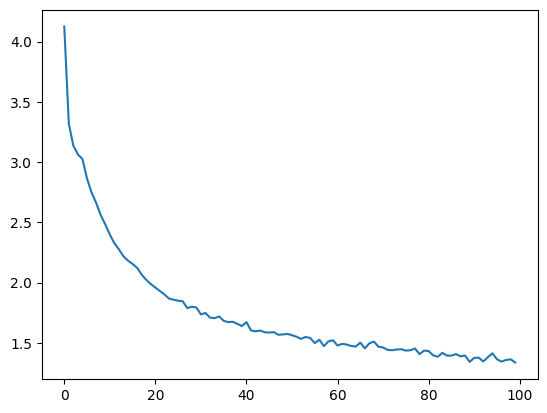

In [5]:
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader
from torch.optim import AdamW

torch.set_float32_matmul_precision("high")

# Dataset.
SEQ_LEN = 128
BATCH_SIZE = 128

# Model.
N_LAYERS = 1
EMBED_DIM = 512
HIDDEN_DIM = 512

# Training
LR = 1e-3
N_STEPS = 1_000


def get_infinite_dataloader(dataloader):
    while True:
        for batch in dataloader:
            yield batch


dataset = TinyShakespeare(SEQ_LEN)
dataloader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2, drop_last=True)
dl_iter = get_infinite_dataloader(dataloader)

model = CharRNN(vocab_size=dataset.vocab_size, n_layers=N_LAYERS, embed_dim=EMBED_DIM, hidden_dim=HIDDEN_DIM, recur_layer=LSTM).to("cuda")
model.compile()
optim = AdamW(model.parameters(), lr=LR, betas=(0.9, 0.999), weight_decay=0.01)

losses = []
for step in range(N_STEPS):
    x, y = next(dl_iter)
    x, y = x.to("cuda"), y.to("cuda")

    logits, _ = model(x)
    loss = F.cross_entropy(logits.view(BATCH_SIZE * SEQ_LEN, dataset.vocab_size), y.view(BATCH_SIZE * SEQ_LEN))

    optim.zero_grad()
    loss.backward()
    optim.step()

    if step % 10 == 0:
        losses.append(loss.item())
    if step % 100 == 0:
        print(f"{step}: loss = {loss:.5f}")
        print("ROMEO" + model.sample(dataset, "ROMEO", n_tokens=1000, device=logits.device))

plt.plot(losses)
plt.show()